# Streaming Issues

Jimmy Butler, November 2025

As I was just about to put the finishing touches on my code to stream data for the entirety of the AR catalog, we ran into some new fun issues! I wanted to test my code on a small subset of ARs (just the first 15 in the catalog). I had tested variations of the workflow numerous times before, and had also confirmed the exact code I had already written had worked on these 15 ARs, on Thursday, November 27. However, upon running on Sunday, November 30, I'm now getting the following error.

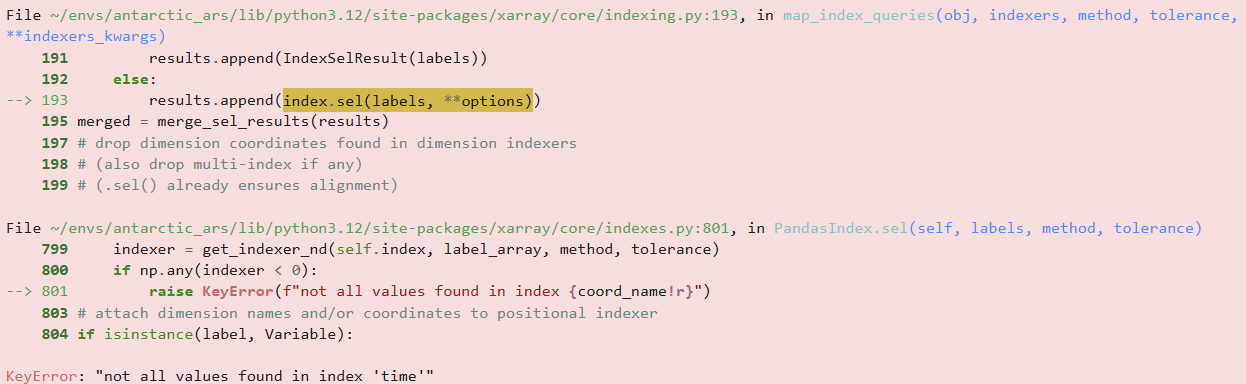

Weirdly, it appears for AR 14. AR 14 lasts from 1/14/1980-1/16/1980. I check the days that were streamed for that AR, and notably it is only 1/14/1980 and 1/16/1980, with no 1/15. At this point, I wasn't sure if it was an Earthaccess issue with accessing MERRA-2 data on that day for whatever reason, or an actual issue with the NASA data centers. Sure enough, when I tried to download data from this date myself from NASA directly, I got the following error:

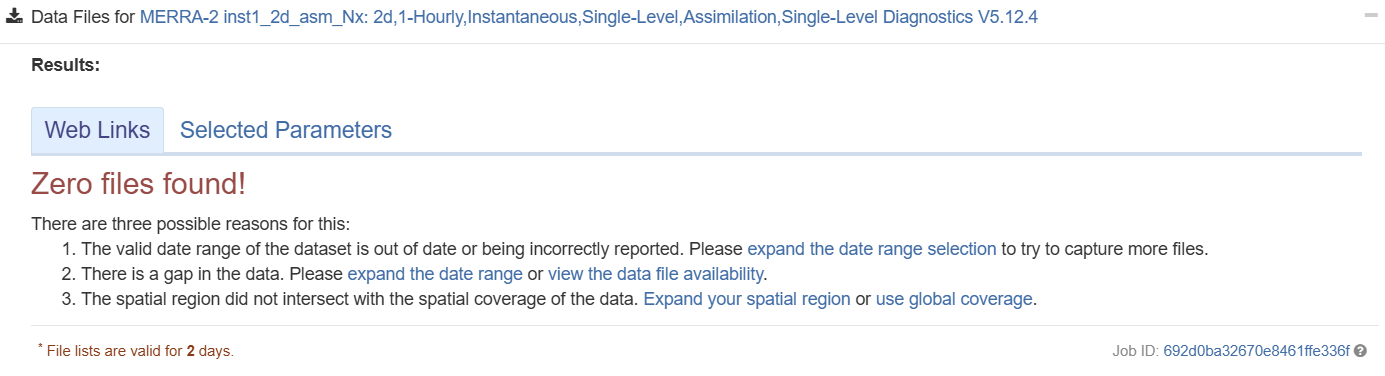

So, it appears that 1/15/1980 has been dropped from the MERRA-2 data repo (DOI: 10.5067/3Z173KIE2TPD). Really weird! I'm going to try to go through with my workflow anyway, catching and logging any of these errors that are thrown to get a sense of how massive/impactful this problem is. I imagine if there's one day that got seemingly erroneously dropped, there might be more.

### Update 12/1/2025

Checking the next morning, it seems that at least 1/15/1980 is back. I'll still account for this in my code, just in case.

In [6]:
import earthaccess

data_doi = '10.5067/3Z173KIE2TPD'

granule_lst = earthaccess.search_data(doi=data_doi, 
                                  temporal=('1980-01-15', 
                                            '1980-01-15'))

In [7]:
granule_lst

[Collection: {'ShortName': 'M2I1NXASM', 'Version': '5.12.4'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180.0, 'EastBoundingCoordinate': 180.0, 'NorthBoundingCoordinate': 90.0, 'SouthBoundingCoordinate': -90.0}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '1980-01-15T00:00:00.000Z', 'EndingDateTime': '1980-01-15T23:00:00.000Z'}}
 Size(MB): 197.70703220367432
 Data: ['https://data.gesdisc.earthdata.nasa.gov/data/MERRA2/M2I1NXASM.5.12.4/1980/01/MERRA2_100.inst1_2d_asm_Nx.19800115.nc4']]